In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import os
import kagglehub

Пример использования функции ARIMA

https://www.statsmodels.org/dev/examples/notebooks/generated/tsa_arma_0.html

Справка по функции ARIMA

https://www.statsmodels.org/dev/generated/statsmodels.tsa.arima.model.ARIMA.html#statsmodels.tsa.arima.model.ARIMA

Датасеты

https://www.kaggle.com/datasets/shenba/time-series-datasets?select=Electric_Production.csv

### Загрузка временных рядов

In [4]:
dir_name = kagglehub.dataset_download("shenba/time-series-datasets")
print("Path to dataset files:", dir_name)

Path to dataset files: C:\Users\D\.cache\kagglehub\datasets\shenba\time-series-datasets\versions\1


In [5]:
file_names = []
for root, dirs, files in os.walk(dir_name, topdown = False):
    for file in files:
        path = root + '\\' + file
        file_names.append(path)

In [6]:
file_names

['C:\\Users\\D\\.cache\\kagglehub\\datasets\\shenba\\time-series-datasets\\versions\\1\\daily-minimum-temperatures-in-me.csv',
 'C:\\Users\\D\\.cache\\kagglehub\\datasets\\shenba\\time-series-datasets\\versions\\1\\Electric_Production.csv',
 'C:\\Users\\D\\.cache\\kagglehub\\datasets\\shenba\\time-series-datasets\\versions\\1\\monthly-beer-production-in-austr.csv',
 'C:\\Users\\D\\.cache\\kagglehub\\datasets\\shenba\\time-series-datasets\\versions\\1\\sales-of-shampoo-over-a-three-ye.csv']

In [20]:
data1 = pd.read_csv(file_names[0], index_col = 0)
data1.index = pd.to_datetime(data1.index, format = '%m/%d/%Y')
data1['Daily minimum temperatures'] = data1['Daily minimum temperatures'].str.replace('?','-').astype(float)
data1 = data1.resample('ME').mean()

data2 = pd.read_csv(file_names[1], index_col = 0)
data2.index = pd.to_datetime(data2.index, format = '%m/%d/%Y')
data2['IPG2211A2N'] = data2['IPG2211A2N'].astype(float)

data3 = pd.read_csv(file_names[2], index_col = 0)
data3.index = pd.to_datetime(data3.index, format = '%Y-%m')
data3['Monthly beer production'] = data3['Monthly beer production'].astype(float)

data4 = pd.read_csv(file_names[3], index_col = 0)
data4.index = pd.to_datetime(["200" + i for i in data4.index], format = '%Y-%b')
data4['Sales of shampoo over a three year period'] = data4['Sales of shampoo over a three year period'].astype(float)

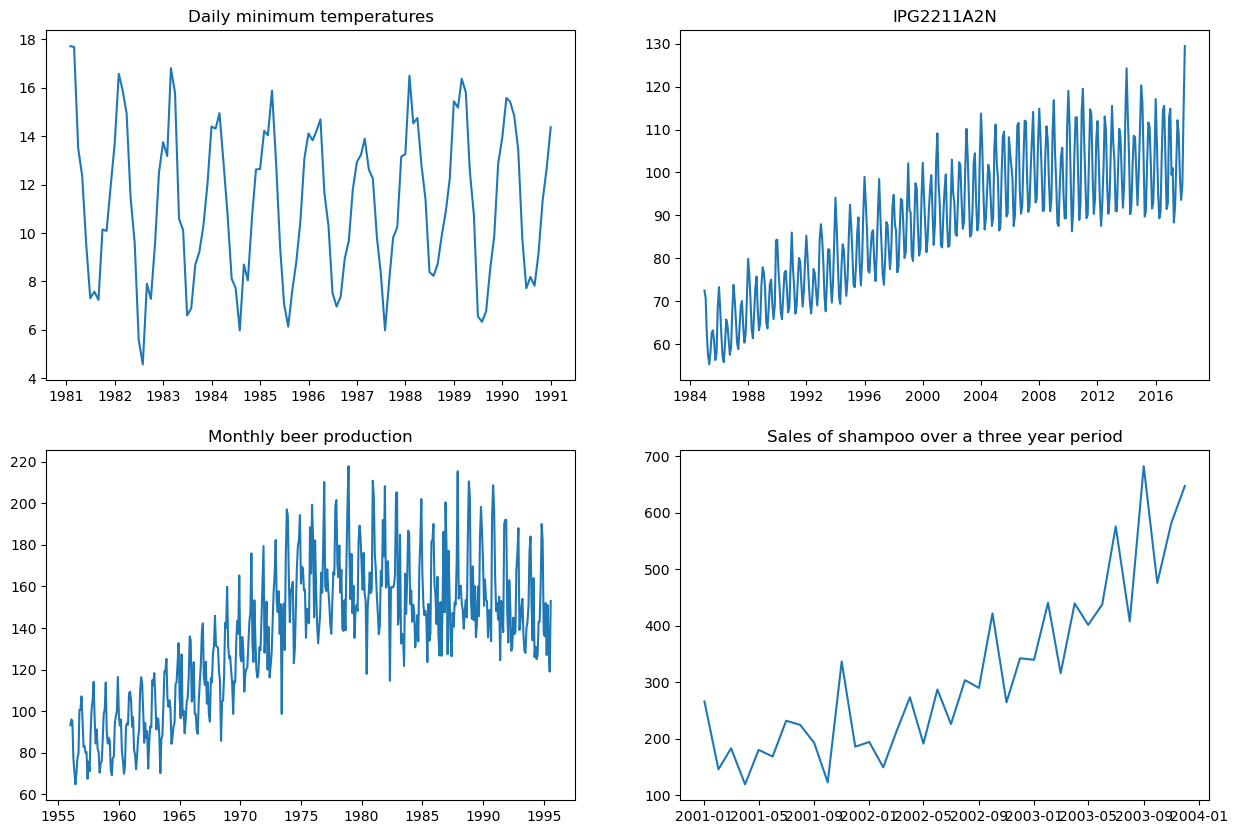

In [22]:
fig, ax = plt.subplots(2,2, figsize = (15,10))
ax[0,0].plot(data1)
ax[0,0].set_title(data1.columns[0])
ax[0,1].plot(data2)
ax[0,1].set_title(data2.columns[0])
ax[1,0].plot(data3)
ax[1,0].set_title(data3.columns[0])
ax[1,1].plot(data4)
ax[1,1].set_title(data4.columns[0])
plt.show()

### Общий алгоритм моделирования временных рядов

1) Визуально изучаем временной ряд, оцениваем возможность наличия детерминированного тренда и сезонности

2) Строим функции автокорреляции и частичной автокорреляции, чтобы понять наличие сезонности и порядок модели ARMA

3) Проводим тест Дики-Фуллера для временного ряда. Нулевая гипотеза: временной ряд нестационарный!

3a) Если гипотеза отвергается, то двигаемся дальше. Порядок интеграции равен 0

3б) Если гипотеза не отвергается, то берем первые разницы и проводим тест для них. Если первые разницы стационарны, то двигаемся дальше. Порядок интеграции равен 1. Если и они не стационарные, берем вторые разницы и делаем снова тот же тест.

Обычно в практике дальше вторых разниц не "ходят", потому что практическая интерпретация пропадает

4) Для тренда оцениваем его форму - нет тренда (c), линейный (ct) или квадратичный (ctt)

5) Для сезонности оцениваем потенциальную частоту - месяц (12) или квартал (4)

6) Делим ряд на тренинговую и тестовую части. Пропорции разделения зависят от того, на какой горизонт требуется дальнейшее прогнозирование

7) На основе тренинговой части оцениваются параметры модели

8) После оценки параметров модели тестируются остатки модели на отсутствие автокорреляции и на нормальность

9) Следует оценить качество модели на тестовой выборке на основе метрик R2, MAE, MAPE, MSE, RMSE

10) Следует так же сравнить несколько моделей на их качество out-of_sample с помощью метрик качества

### Загружаем функцию теста на стационарность

In [23]:
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries, regression):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC", regression = regression)
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

### Проводим анализ временных рядов

#### Графики ACF и PACF

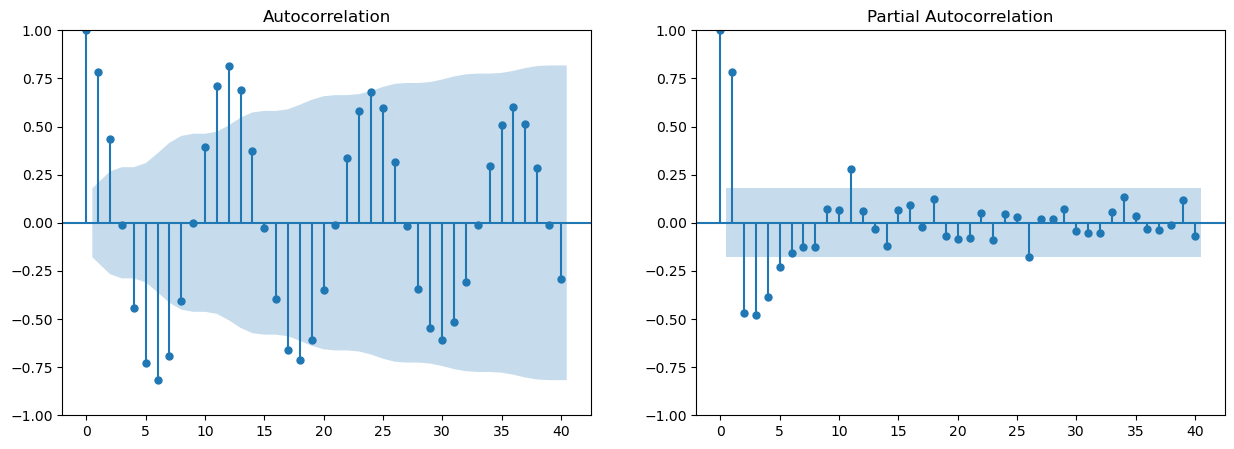

In [24]:
fig,ax = plt.subplots(1, 2, figsize=(15, 5))
sm.graphics.tsa.plot_acf(data1, lags=40, ax=ax[0])
sm.graphics.tsa.plot_pacf(data1, lags=40, ax=ax[1])
plt.show()

График ACF затухает плавно и равномерно

График PACF затухает быстро на 5 лаге

Это дает основания считать, что модель AR для временного ряда будет более уместна

#### Тест на стационарность

In [25]:
adf_test(data1, regression = 'c')

Results of Dickey-Fuller Test:
Test Statistic                  -1.895775
p-value                          0.334051
#Lags Used                      13.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64


Тест Дики-Фуллера имеет нулевую гипотезу, что ряд нестационарный

р-значение = 0,33 > 0,05 => нулевую не отвергаем => ряд нестационарный

Что делать?

Для того, чтобы сделать ряд стационарным берутся первые разницы

<Axes: xlabel='Date'>

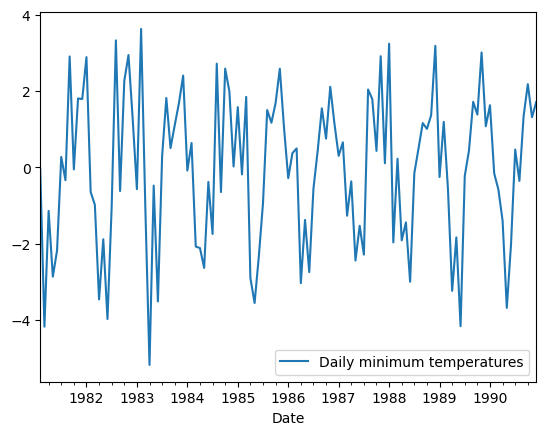

In [26]:
first_diff = data1.diff().dropna()
first_diff.plot()

In [27]:
adf_test(first_diff, regression = 'c')

Results of Dickey-Fuller Test:
Test Statistic                  -4.626141
p-value                          0.000116
#Lags Used                      12.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64


Проверка первых разниц показала, что они стационарные => порядок интеграции = 1

#### Делим данные на тренинговую и тестовую части

In [28]:
data1.shape

(120, 1)

In [29]:
train = data1[:100]
test = data1[100:]

In [30]:
train

,Daily minimum temperatures
Date,
1981-01-31,17.712903
1981-02-28,17.678571
1981-03-31,13.500000
1981-04-30,12.356667
1981-05-31,9.490323
...,...
1988-12-31,15.436667
1989-01-31,15.180645
1989-02-28,16.371429


In [31]:
test

,Daily minimum temperatures
Date,
1989-05-31,10.725806
1989-06-30,6.560000
1989-07-31,6.332258
1989-08-31,6.770968
1989-09-30,8.486667
1989-10-31,9.867742
1989-11-30,12.876667
1989-12-31,13.951613
1990-01-31,15.577419


In [15]:
train.shape

(100, 1)

In [16]:
test.shape

(20, 1)

#### Оцениваем модель ARIMA

ARIMA:

AR - autoregressive (AR - часть)

I - integrated (порядок интеграции)

MA - moving average (MA - часть)

I - сколько раз нужно было взять разности, прежде чем ряд стал стационарным

In [34]:
model = ARIMA(endog = train, order = (1,1,0), seasonal_order=(1, 1, 0, 12), trend = None, freq = 'ME')
res = model.fit()

Параметры order = (p, 1, q) лучше всего подбирать таким образом, чтобы качество прогнозирования было как можно выше

In [35]:
print(res.summary())

                                    SARIMAX Results                                     
Dep. Variable:       Daily minimum temperatures   No. Observations:                  100
Model:             ARIMA(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -146.669
Date:                          Tue, 15 Sep 2026   AIC                            299.338
Time:                                  19:02:58   BIC                            306.736
Sample:                              01-31-1981   HQIC                           302.317
                                   - 04-30-1989                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5816      0.080     -7.233      0.000      -0.739      -0.424
ar.S.L12      -0.4509      0.095     -4.745      0.

$\Delta Y_t = -0.5816 \cdot \Delta Y_{t-1} - 0.4509 \cdot \Delta Y_{t-12}$

$\varepsilon_t \sim (0, 1.645)$

Для каждого коэффициента оценивается, насколько он значимо отличается от нуля

Нулевая гипотеза: коэффициент равен нулю

р-значения для каждого коэффициента меньше 0,05 (они меньше 0,001, но какие - мы не знаем)

Все коэффициенты отличаются от нуля

#### Получаем остатки для модели

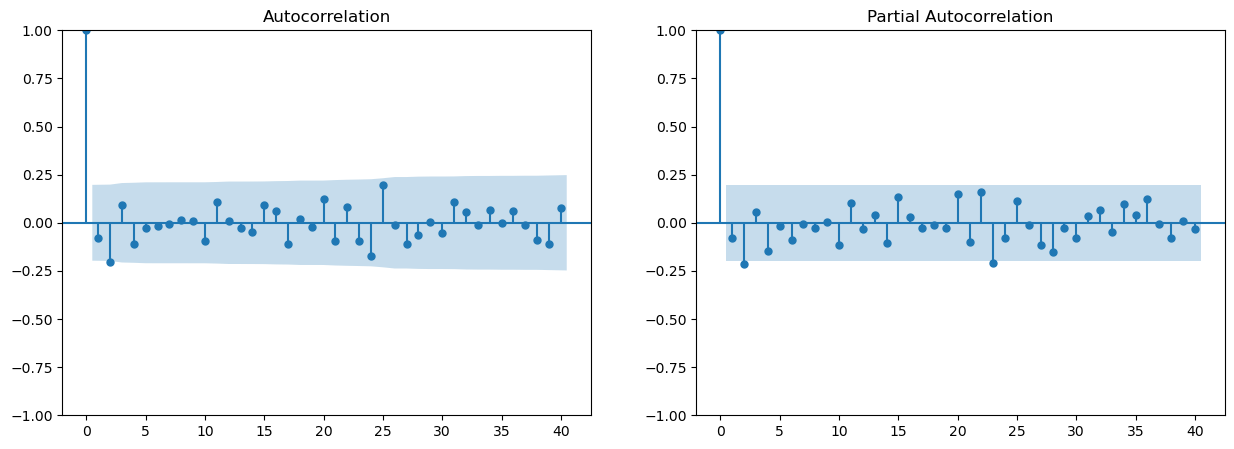

In [36]:
residuals = res.resid[1:]

fig,ax = plt.subplots(1, 2, figsize=(15, 5))
sm.graphics.tsa.plot_acf(residuals, lags=40, ax=ax[0])
sm.graphics.tsa.plot_pacf(residuals, lags=40, ax=ax[1])
plt.show()

Судя по графикам ACF и PACF, остатки в моделе не имеют какой-либо структуры и их можно считать белым шумом

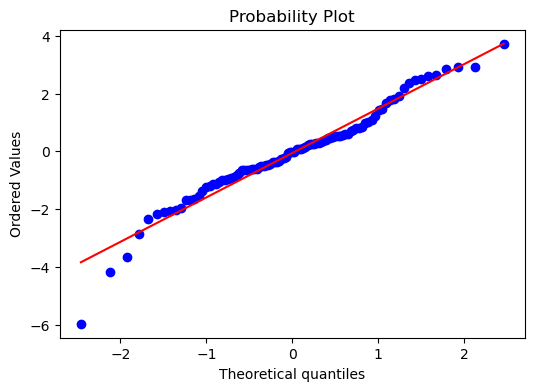

In [37]:
fig, ax = plt.subplots(figsize = (6,4))
plt.title('QQ-plot для остатков')
stats.probplot(residuals, dist="norm", plot = ax)
plt.show()

<Axes: >

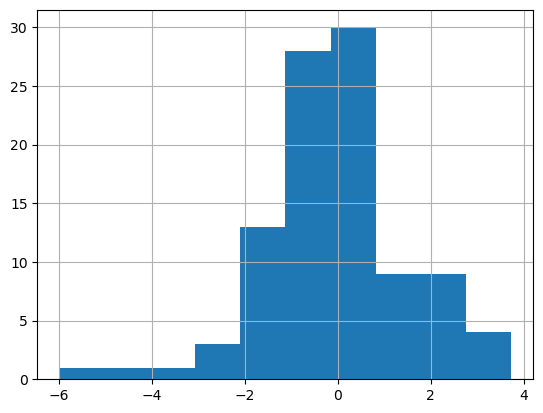

In [38]:
residuals.hist()

In [39]:
print(stats.shapiro(residuals))

ShapiroResult(statistic=np.float64(0.9658297601758756), pvalue=np.float64(0.011274786834305772))


In [40]:
print(stats.anderson(residuals, dist='norm'))

AndersonResult(statistic=np.float64(0.8792476558194267), critical_values=array([0.555, 0.632, 0.758, 0.885, 1.052]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(-0.05827444451769418), scale=np.float64(1.5468591481740823))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


In [41]:
print(stats.kstest(residuals, stats.norm.cdf))

KstestResult(statistic=np.float64(0.09463793785984531), pvalue=np.float64(0.3176350219771712), statistic_location=np.float64(1.7906443398228173), statistic_sign=np.int8(-1))


### Строим прогноз

In [25]:
train

,Daily minimum temperatures
Date,
1981-01-31,17.712903
1981-02-28,17.678571
1981-03-31,13.500000
1981-04-30,12.356667
1981-05-31,9.490323
...,...
1988-12-31,15.436667
1989-01-31,15.180645
1989-02-28,16.371429


In [43]:
pred_vals = res.forecast(steps = len(test))
pred_vals

1989-05-31    11.843283
1989-06-30     8.820615
1989-07-31     8.101178
1989-08-31     9.060170
1989-09-30    10.636293
1989-10-31    11.304256
1989-11-30    13.410970
1989-12-31    15.179597
1990-01-31    16.514907
1990-02-28    16.271659
1990-03-31    16.066017
1990-04-30    13.420527
1990-05-31    12.374767
1990-06-30     9.361102
1990-07-31     8.897059
1990-08-31     9.645814
1990-09-30    11.033374
1990-10-31    11.854103
1990-11-30    13.625515
1990-12-31    16.032059
Freq: ME, Name: predicted_mean, dtype: float64

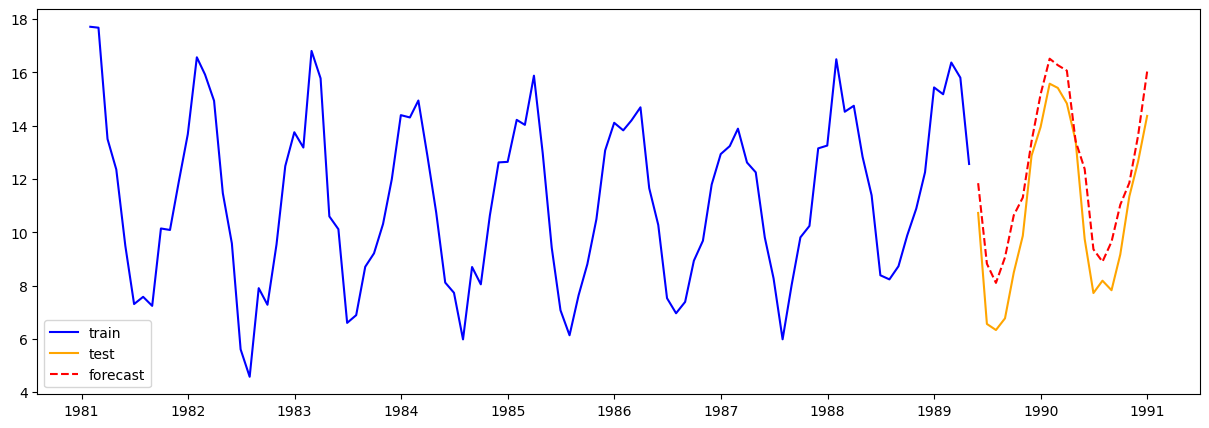

In [44]:
fig, ax = plt.subplots(figsize = (15,5))
ax.plot(train, color = 'blue', label = 'train')
ax.plot(test, color = 'orange', label = 'test')
ax.plot(pred_vals, color = 'red', linestyle = 'dashed', label = 'forecast')
plt.legend()
plt.show()

### Оцениваем качество прогноза

In [45]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error 

In [46]:
print('R-squared равен:', r2_score(test, pred_vals))
print('MAE равен:', mean_absolute_error(test, pred_vals))
print('MSE равен:', mean_squared_error(test, pred_vals))
print('RMSE равен:', np.sqrt(mean_squared_error(test, pred_vals)))
print('MAPE равен:', mean_absolute_percentage_error(test, pred_vals))

R-squared равен: 0.7482127914982664
MAE равен: 1.381438053535917
MSE равен: 2.359658571240478
RMSE равен: 1.5361180199582576
MAPE равен: 0.15183327942199457


R-squared - чем выше, тем лучше. Принимет значения от 0 до 1

Остальные метрики - чем ниже, тем лучше. Это различные вариации средней ошибки прогнозирования

### Строим прогноз с доверительным интервалом

In [54]:
pred_int = model1.get_forecast(steps = len(test))

In [58]:
pred_int.predicted_mean

1989-05-31    11.843282
1989-06-30     8.820615
1989-07-31     8.101178
1989-08-31     9.060170
1989-09-30    10.636292
1989-10-31    11.304255
1989-11-30    13.410969
1989-12-31    15.179597
1990-01-31    16.514906
1990-02-28    16.271659
1990-03-31    16.066016
1990-04-30    13.420526
1990-05-31    12.374766
1990-06-30     9.361102
1990-07-31     8.897058
1990-08-31     9.645813
1990-09-30    11.033374
1990-10-31    11.854102
1990-11-30    13.625514
1990-12-31    16.032058
Freq: ME, Name: predicted_mean, dtype: float64

In [60]:
pred_int.conf_int()

,lower Daily minimum temperatures,upper Daily minimum temperatures
1989-05-31,9.329489,14.357075
1989-06-30,6.095661,11.545568
1989-07-31,4.778033,11.424323
1989-08-31,5.451228,12.669111
1989-09-30,6.649057,14.623528
1989-10-31,7.034305,15.574205
1989-11-30,8.842198,17.979740
1989-12-31,10.349055,20.010139
1990-01-31,11.425806,21.604006
1990-02-28,10.942231,21.601086


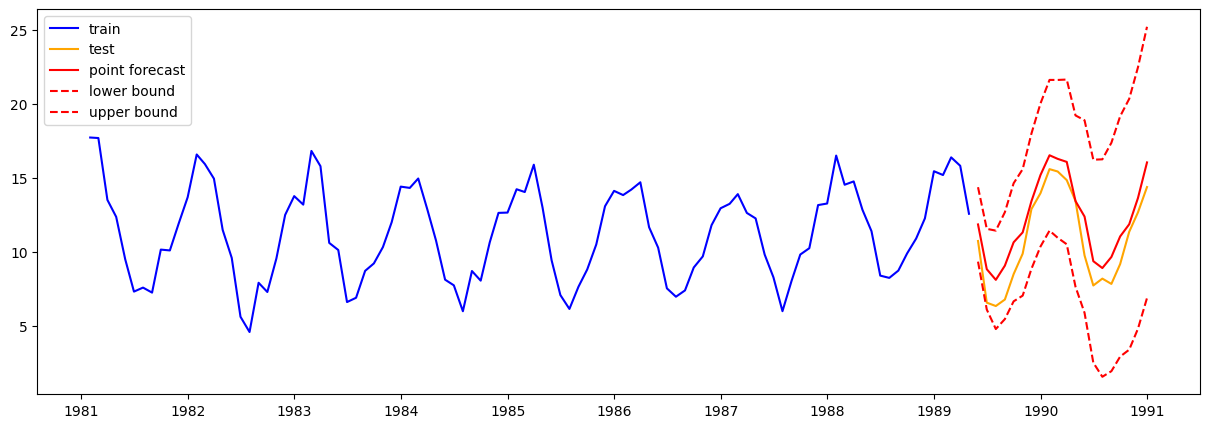

In [62]:
fig, ax = plt.subplots(figsize = (15,5))
ax.plot(train, color = 'blue', label = 'train')
ax.plot(test, color = 'orange', label = 'test')
ax.plot(pred_int.predicted_mean, color = 'red', linestyle = 'solid', label = 'point forecast')
ax.plot(pred_int.conf_int().iloc[:,0], color = 'red', linestyle = 'dashed', label = 'lower bound')
ax.plot(pred_int.conf_int().iloc[:,1], color = 'red', linestyle = 'dashed', label = 'upper bound')
plt.legend()
plt.show()

### Подбор параметров для наиболее точной модели

In [66]:
results_df = pd.DataFrame()

for p in range(4):
    for q in range(4):
        model = ARIMA(endog = train, order = (p,1,q), seasonal_order=(1, 1, 0, 12), trend = None, freq = 'ME').fit()
        pred_vals = model.forecast(steps = len(test))
        r2 = r2_score(test, pred_vals)
        mae = mean_absolute_error(test, pred_vals)
        mse = mean_squared_error(test, pred_vals)
        rmse = np.sqrt(mean_squared_error(test, pred_vals))
        mape = mean_absolute_percentage_error(test, pred_vals)
        
        temp_df = pd.DataFrame({'p': [p], 'q': [q], 'r2': [r2], 'mae': [mae], 'mse': [mse], 'rmse': [rmse], 'mape': [mape]})
        results_df = pd.concat([results_df, temp_df])
        

C:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarni

In [67]:
results_df

,p,q,r2,mae,mse,rmse,mape
0,0,0,0.924752,0.682327,0.705197,0.839760,0.079147
0,0,1,0.659591,1.641511,3.190190,1.786110,0.178836
0,0,2,0.629050,1.725294,3.476412,1.864514,0.187308
0,0,3,0.674695,1.604177,3.048642,1.746036,0.174515
0,1,0,0.748213,1.381438,2.359657,1.536118,0.151833
0,1,1,0.623390,1.740821,3.529449,1.878683,0.188839
0,1,2,0.666251,1.617123,3.127771,1.768551,0.176580
0,1,3,0.694352,1.544510,2.864421,1.692460,0.168522
0,2,0,0.597881,1.803124,3.768518,1.941267,0.194738
0,2,1,0.682799,1.580852,2.972694,1.724150,0.172289


### Финальная оценка выбранной модели 

In [69]:
model2 = ARIMA(endog = train, order = (0,1,0), seasonal_order=(1, 1, 0, 12), trend = None, freq = 'ME').fit()
print(model2.summary())

                                    SARIMAX Results                                     
Dep. Variable:       Daily minimum temperatures   No. Observations:                  100
Model:             ARIMA(0, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -164.043
Date:                          Fri, 25 Oct 2024   AIC                            332.085
Time:                                  19:47:47   BIC                            337.017
Sample:                              01-31-1981   HQIC                           334.071
                                   - 04-30-1989                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.5295      0.112     -4.722      0.000      -0.749      -0.310
sigma2         2.4299      0.398      6.104      0.

#### Анализируем остатки

<Axes: xlabel='Date'>

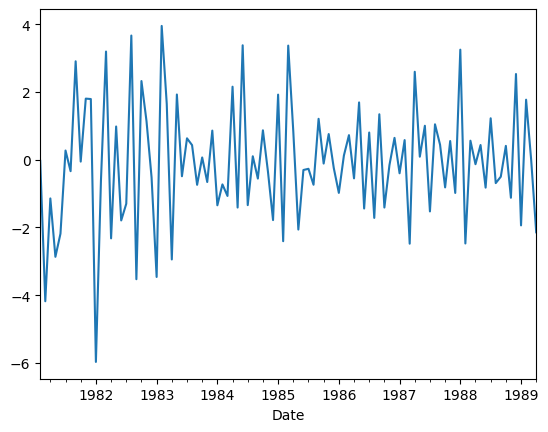

In [74]:
residuals.plot()

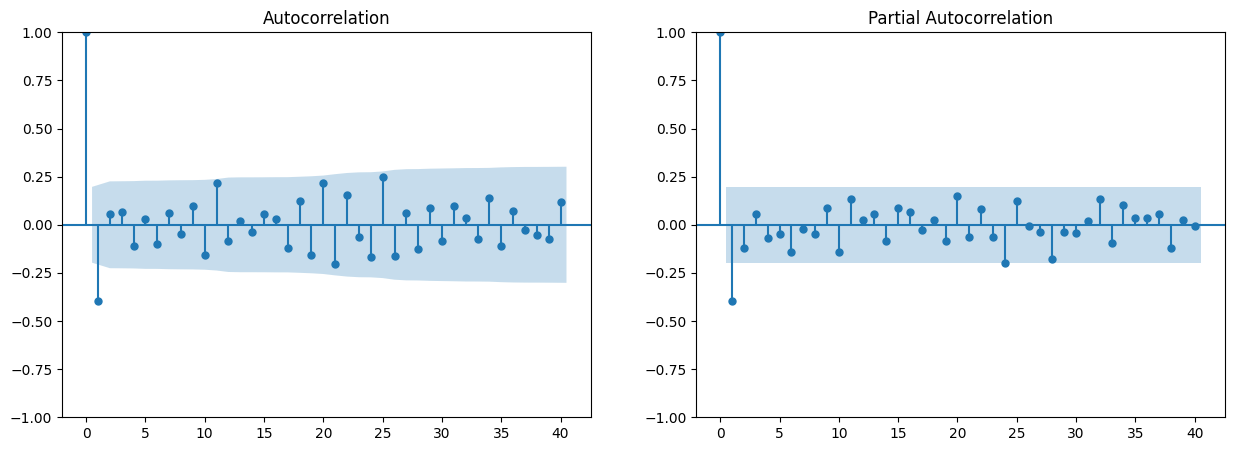

In [73]:
residuals = model2.resid[1:]

fig,ax = plt.subplots(1, 2, figsize=(15, 5))
sm.graphics.tsa.plot_acf(residuals, lags=40, ax=ax[0])
sm.graphics.tsa.plot_pacf(residuals, lags=40, ax=ax[1])
plt.show()

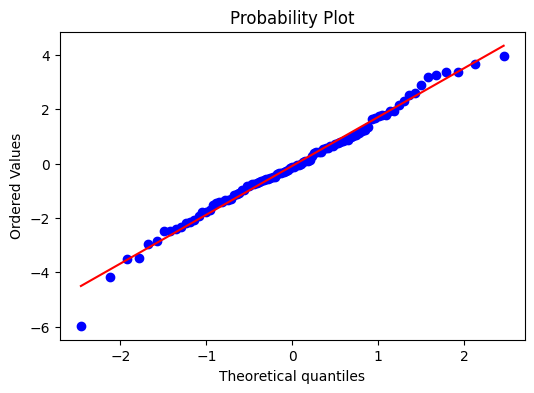

In [71]:
fig, ax = plt.subplots(figsize = (6,4))
plt.title('QQ-plot для остатков')
stats.probplot(residuals, dist="norm", plot = ax)
plt.show()

In [72]:
print(stats.shapiro(residuals))

ShapiroResult(statistic=np.float64(0.9888430665288842), pvalue=np.float64(0.5795188807424734))


#### Пробуем строить прогноз по новой модели

In [75]:
pred_int = model2.get_forecast(steps = len(test))

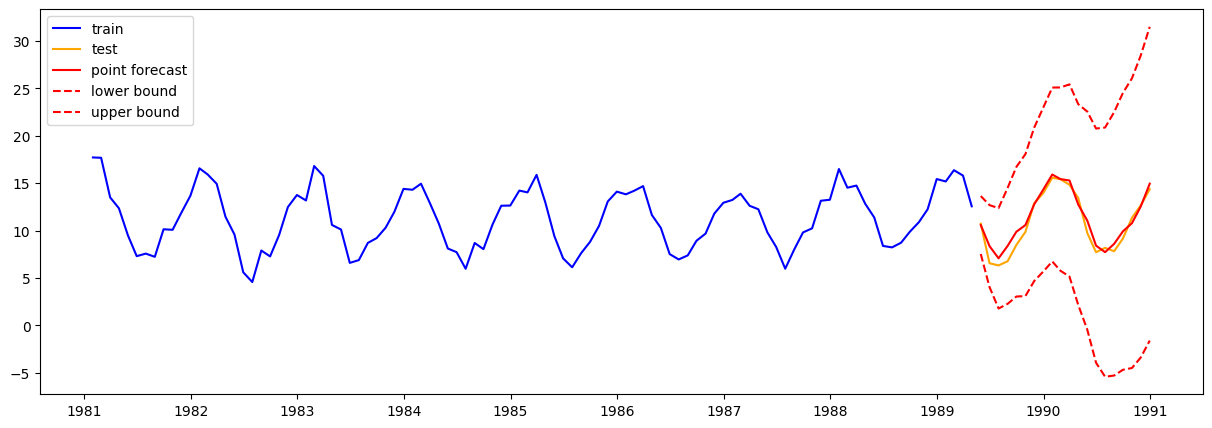

In [77]:
fig, ax = plt.subplots(figsize = (15,5))
ax.plot(train, color = 'blue', label = 'train')
ax.plot(test, color = 'orange', label = 'test')
ax.plot(pred_int.predicted_mean, color = 'red', linestyle = 'solid', label = 'point forecast')
ax.plot(pred_int.conf_int().iloc[:,0], color = 'red', linestyle = 'dashed', label = 'lower bound')
ax.plot(pred_int.conf_int().iloc[:,1], color = 'red', linestyle = 'dashed', label = 'upper bound')
plt.legend()
plt.show()

In [78]:
pred_int.conf_int()

,lower Daily minimum temperatures,upper Daily minimum temperatures
1989-05-31,7.533864,13.644269
1989-06-30,4.044801,12.686219
1989-07-31,1.788923,12.372455
1989-08-31,2.281924,14.502734
1989-09-30,3.051714,16.714995
1989-10-31,3.100485,18.067859
1989-11-30,4.683619,20.850231
1989-12-31,5.678920,22.961755
1990-01-31,6.749007,25.080222
1990-02-28,5.770823,25.093620
